# Malden car crash data 2025

## Contents
* Download car crash data from MassDOT Crash Portal: https://apps.crashdata.dot.mass.gov/cdv/
* Load SHP file of town boundaries from GIS
* Use the boundaries to filter out crashes outside Malden
* Plot car crashes that involved, pedestrians, cyclsts, and other vulnerable users

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

### Load car crash data for Malden
This was download from the MassDOT crash portal

In [2]:
raw_crashes_df = pd.read_csv('../data_sources/Malden_crashes_2025.csv', low_memory=False)

### Get the Malden boundaries from the Massacussets GIS town SHP file
This is used to include only crashes within Malden

<Axes: >

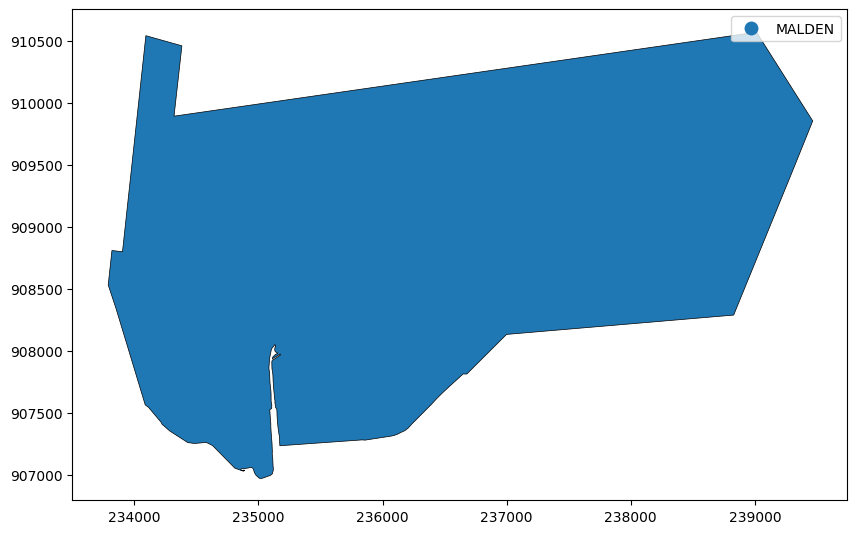

In [3]:
mass_town_survey_file = '../GIS/townssurvey_shp/TOWNSSURVEY_POLY.shp'
towns_gdf = gpd.read_file(mass_town_survey_file)
malden_shp = towns_gdf[towns_gdf['TOWN'] == 'MALDEN']

malden_shp.plot(column='TOWN', legend=True, figsize=(10, 8), cmap='tab20', edgecolor='black', linewidth=0.5)

### Convert the crashes dataframe to a GeoDataFrame for plotting

In [4]:
raw_crashes_gdf = gpd.GeoDataFrame(
    raw_crashes_df,
    geometry=gpd.points_from_xy(raw_crashes_df['Longitude'], raw_crashes_df['Latitude']),
    crs='EPSG:4326'
)

# Make sure both data sets use the same CRS
raw_crashes_gdf = raw_crashes_gdf.to_crs(malden_shp.crs)

# Spatial join - filter for only crashes within Malden
crashes_in_malden = gpd.sjoin(raw_crashes_gdf, malden_shp, predicate='within')

### Plot all crashes and all crashes within Malden
The crashes are plot on top of each other, so the darker the color the more crashes.

Note the red crashes outside Malden.

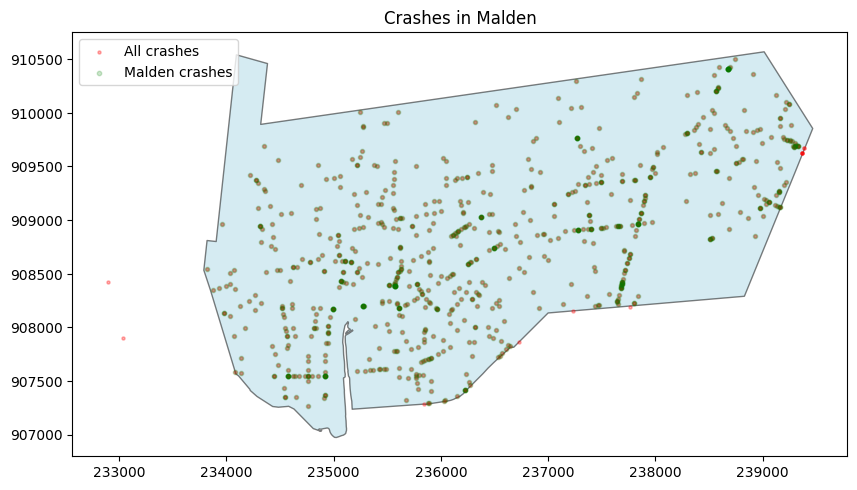

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot Malden boundary from SHP file
malden_shp.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5)

# Plot all crashes in red
raw_crashes_gdf.plot(ax=ax, color='red', markersize=5, alpha=0.3, label='All crashes')

# Plot crashes within Malden in green
crashes_in_malden.plot(ax=ax, color='green', markersize=10, alpha=0.2, label='Malden crashes')

plt.legend()
plt.title('Crashes in Malden')
plt.show()

### Data cleaning
Keep the car crashes that are within and on the border of Malden and omit the points that are well outside the boundaries by using a buffer.

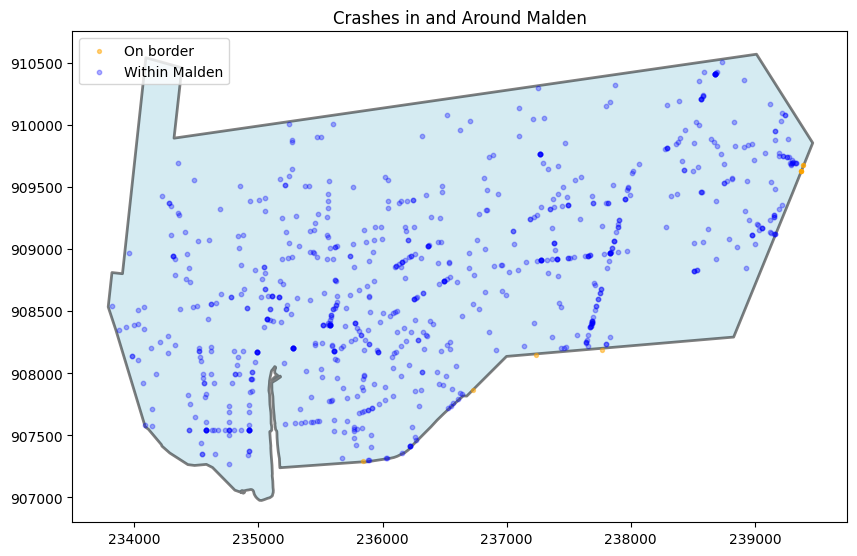

Total crashes in raw dataset: 829
Inside Malden: 798
On border: 10
Outside: 21
Keep: 808


In [6]:
# Create a small buffer around Malden boundary (adjust distance as needed)
buffer_distance = 100
malden_buffered = malden_shp.copy()
malden_buffered['geometry'] = malden_shp.buffer(buffer_distance)

# Classify crashes into within and on border
crashes_within = gpd.sjoin(raw_crashes_gdf, malden_shp, predicate='within')
crashes_in_buffer = gpd.sjoin(raw_crashes_gdf, malden_buffered, predicate='within')

all_indices = set(raw_crashes_gdf.index)
inside_buffer_indices = set(crashes_in_buffer.index)
crashes_outside = raw_crashes_gdf.loc[list(all_indices - inside_buffer_indices)]

# Crashes on the border = in buffer but not strictly within
border_indices = crashes_in_buffer.index.difference(crashes_within.index)
crashes_on_border = raw_crashes_gdf.loc[border_indices]

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot Malden boundary
malden_shp.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5, linewidth=2)

# Plot crashes in within and on border
crashes_on_border.plot(ax=ax, color='orange', markersize=8, alpha=0.5, label='On border')
crashes_within.plot(ax=ax, color='blue', markersize=10, alpha=0.3, label='Within Malden')

plt.legend()
plt.title('Crashes in and Around Malden')
plt.show()

# Combine the crashes within and on the border
malden_crashes_df = pd.concat([
    raw_crashes_df.loc[crashes_within.index],
    raw_crashes_df.loc[crashes_on_border.index]
])

print(f"Total crashes in raw dataset: {len(raw_crashes_gdf)}")
print(f"Inside Malden: {len(crashes_within)}")
print(f"On border: {len(crashes_on_border)}")
print(f"Outside: {len(crashes_outside)}")
print(f"Keep: {len(malden_crashes_df)}")

## Cleaned data
From here, use `malden_crashes_df` that include points within and on the border of Malden

In [7]:
malden_crashes_gdf = gpd.GeoDataFrame(
    malden_crashes_df,
    geometry=gpd.points_from_xy(malden_crashes_df['Longitude'], malden_crashes_df['Latitude']),
    crs='EPSG:4326'
)

<Axes: >

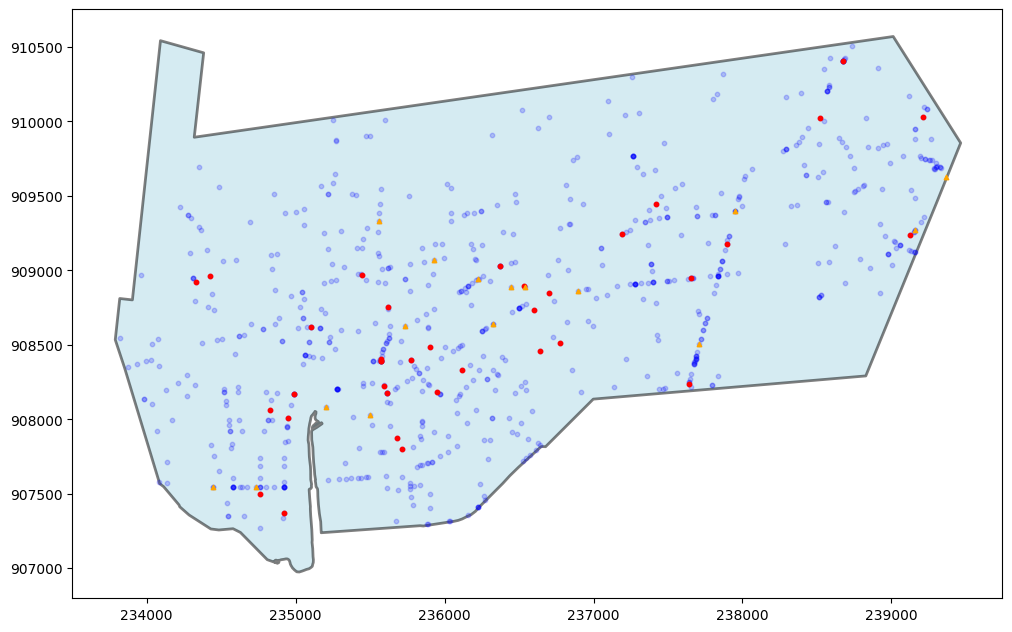

In [9]:
# Filter for crashes that involved pedestrians or cyclists
ped_crashes = malden_crashes_df[malden_crashes_df['First Harmful Event'] == 'Collision with pedestrian']

ped_gdf = gpd.GeoDataFrame(
    ped_crashes,
    geometry=gpd.points_from_xy(ped_crashes['Longitude'], ped_crashes['Latitude']),
    crs='EPSG:4326'
)

ped_gdf = ped_gdf.to_crs(malden_shp.crs)

bike_crashes = malden_crashes_df[malden_crashes_df['First Harmful Event'] == 'Collision with cyclist']
bike_gdf = gpd.GeoDataFrame(
    bike_crashes,
    geometry=gpd.points_from_xy(bike_crashes['Longitude'], bike_crashes['Latitude']),
    crs='EPSG:4326'
)
bike_gdf = bike_gdf.to_crs(malden_shp.crs)

fig, ax = plt.subplots(figsize=(12, 10))

# Plot Malden boundary
malden_shp.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.5, linewidth=2)
#crashes_on_border.plot(ax=ax, color='blue', markersize=8, alpha=0.6, label='On border')
crashes_within.plot(ax=ax, color='blue', markersize=10, alpha=0.2, label='Inside Malden')

ped_gdf.plot(ax=ax, color='red', markersize=10, label='Pedestrian crashes')
bike_gdf.plot(ax=ax, color='orange', marker='^', markersize=10, label='Cyclist crashes')